/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


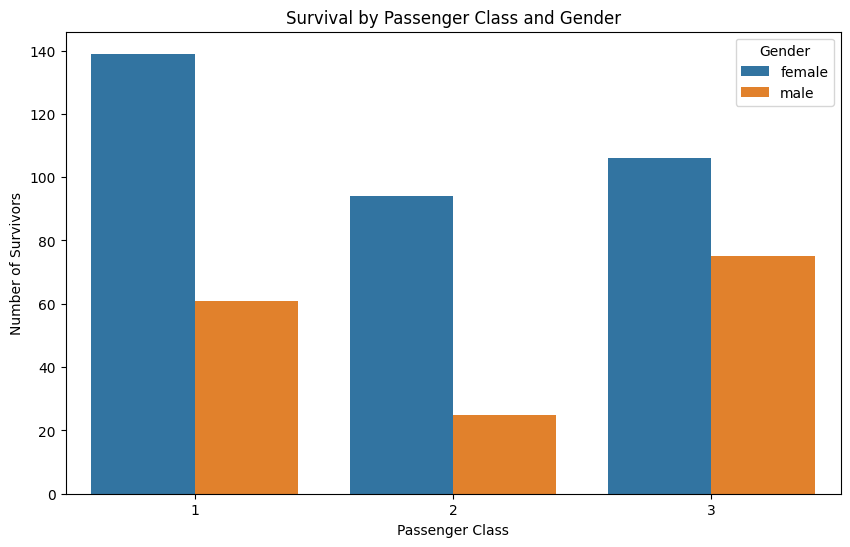

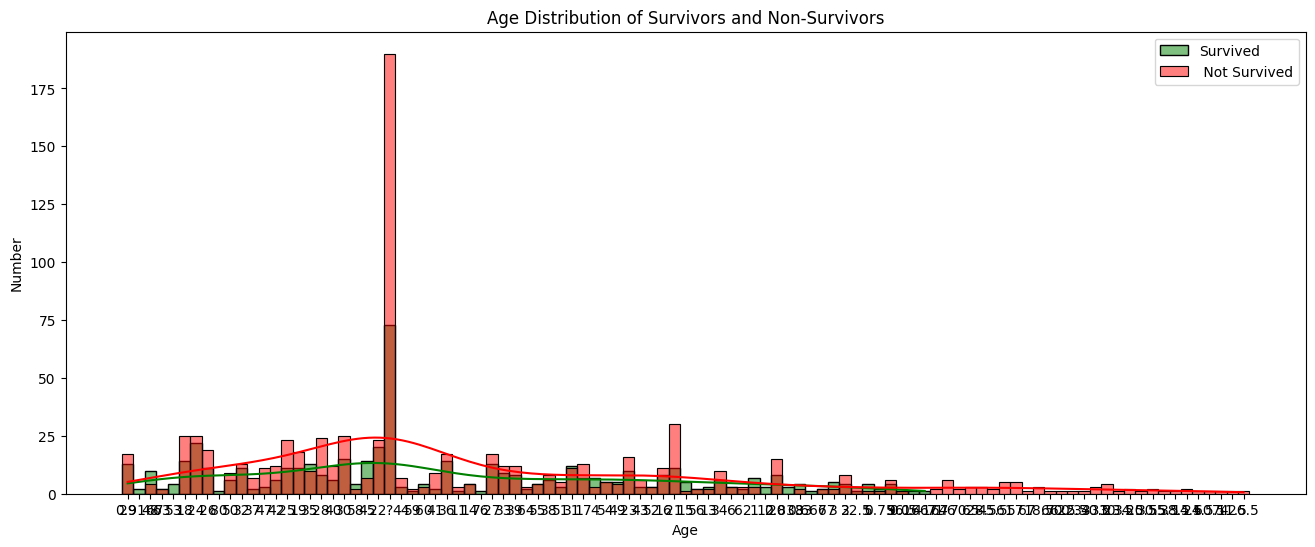

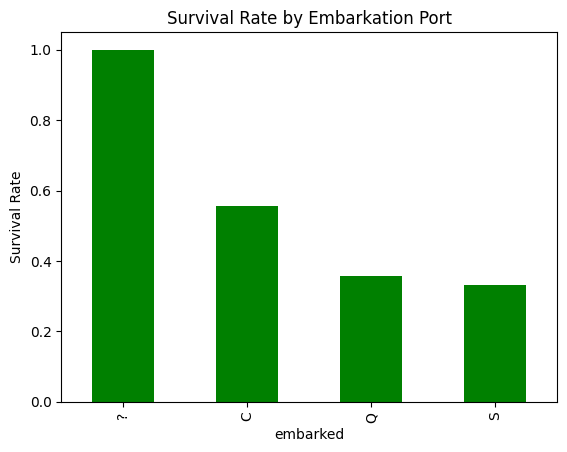

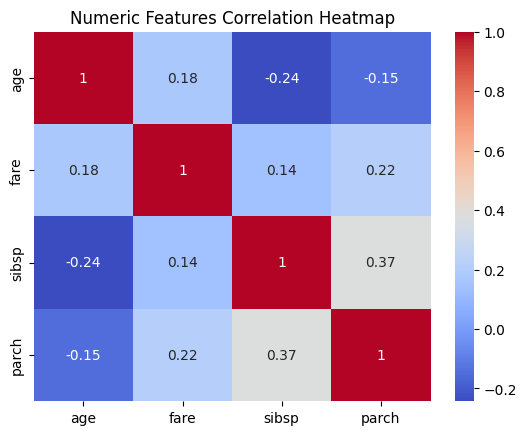

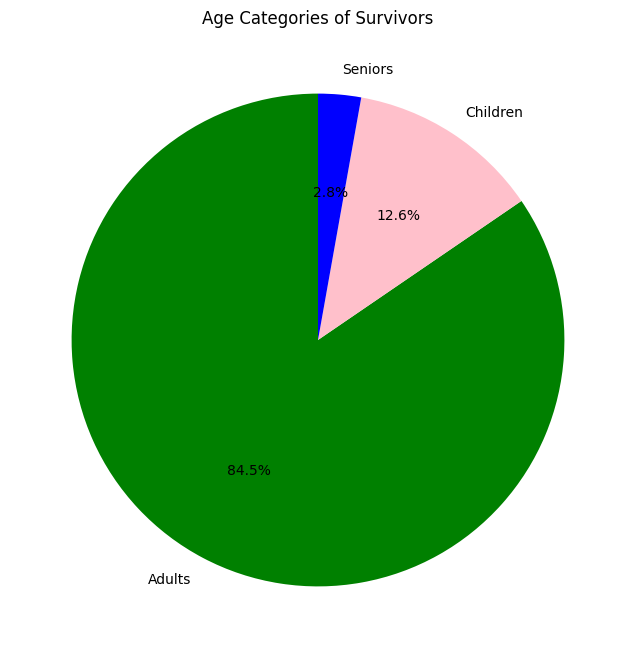

'\nAfter diving the data set into categories we plot the pie chart to show the no.of passengers in percentage and we find that more surviours are from Adult class and\nmore fatality is from children and Seniors class.\n'

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


titanic_df = pd.read_csv('/content/titanic.csv')
titanic_df.head()

#1
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic_df[titanic_df['survived'] == 1], x='pclass', hue='sex')

plt.title('Survival by Passenger Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Survivors')
plt.legend(title='Gender')
plt.show()

'''
from the bar chart we can see that for every class surviours are more from female class than compared to male class.
'''

#2
df_clean = titanic_df.dropna(subset=['age'])
plt.figure(figsize=(16, 6))
sns.histplot(df_clean[df_clean['survived'] == 1]['age'], color='green', label='Survived', kde=True, bins=20)
sns.histplot(df_clean[df_clean['survived'] == 0]['age'], color='red', label=' Not Survived', kde=True, bins=20)

plt.title('Age Distribution of Survivors and Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Number')
plt.legend()
plt.show()

'''
at age on between 23-30 there are more deaths compared to other class and we have a class ? which may be outlier and it is also showing high records.
'''

#3
survival_rate = titanic_df.groupby('embarked')['survived'].mean()

# displaying bar chart for the survivl Rate by the embark port
survival_rate.plot(kind='bar', color='green')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

'''
so considering the survivals we got more survivals from ? port which may be N/A and after that more surviours are from port c and respectively from this we can infer that
people get into titanic very late compared to other ports passenger.
'''

#4
# Replace '?' with NaN
titanic_df[['age', 'fare', 'sibsp', 'parch']] = titanic_df[['age', 'fare', 'sibsp', 'parch']].replace('?', pd.NA)

# Convert columns to numeric (if they were strings before)
titanic_df[['age', 'fare', 'sibsp', 'parch']] = titanic_df[['age', 'fare', 'sibsp', 'parch']].apply(pd.to_numeric)

# Drop rows with missing values
titanic_df_clean = titanic_df[['age', 'fare', 'sibsp', 'parch']].dropna()

# Compute correlation matrix
correl = titanic_df_clean.corr()

# Create heatmap
sns.heatmap(correl, annot=True, cmap='coolwarm')
plt.title('Numeric Features Correlation Heatmap')
plt.show()


'''
The correlation between the number of parents/children (parch) and siblings/spouses (sibsp) aboard is proven inside the heatmap.
although the association is not very sizeable. These two variables show a modest effective correlation of 0.37.
'''
#5
titanic_df['age_category'] = pd.cut(titanic_df['age'], bins=[0, 12, 59, 100], labels=['Children', 'Adults', 'Seniors'])

# Filter for survivors and count the number of survivors in each age category
age_category_survivors = titanic_df[titanic_df['survived'] == 1]['age_category'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(age_category_survivors, labels=age_category_survivors.index, autopct='%1.1f%%', startangle=90, colors=['green', 'pink', 'blue'])
plt.title('Age Categories of Survivors')
plt.show()

'''
After diving the data set into categories we plot the pie chart to show the no.of passengers in percentage and we find that more surviours are from Adult class and
more fatality is from children and Seniors class.
'''


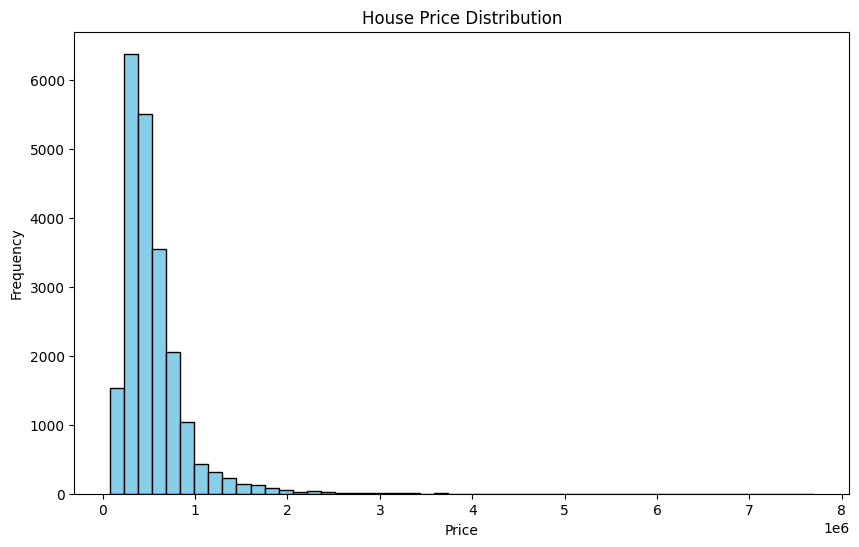

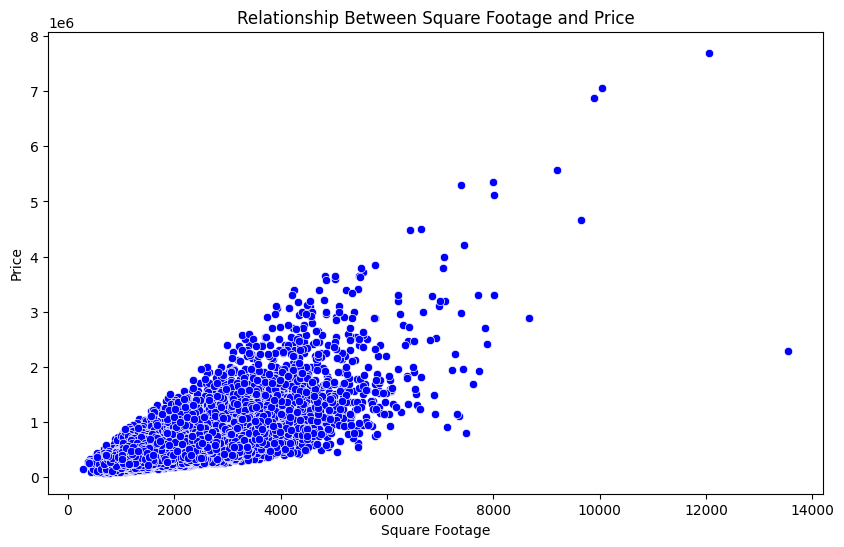

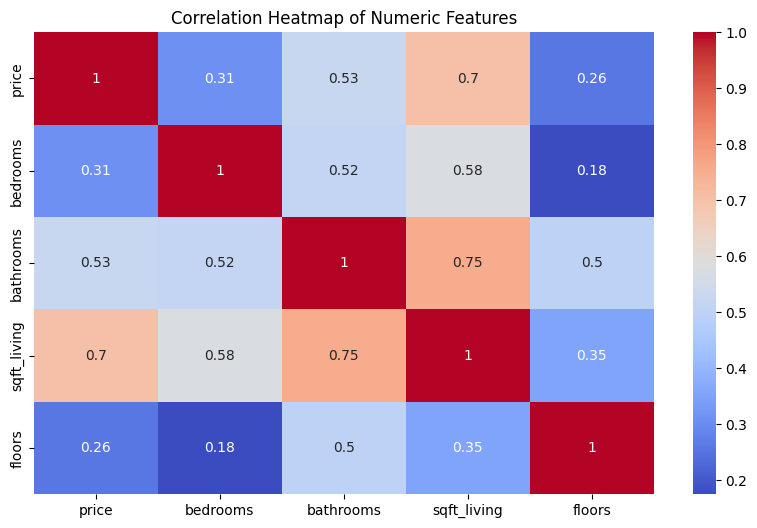

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


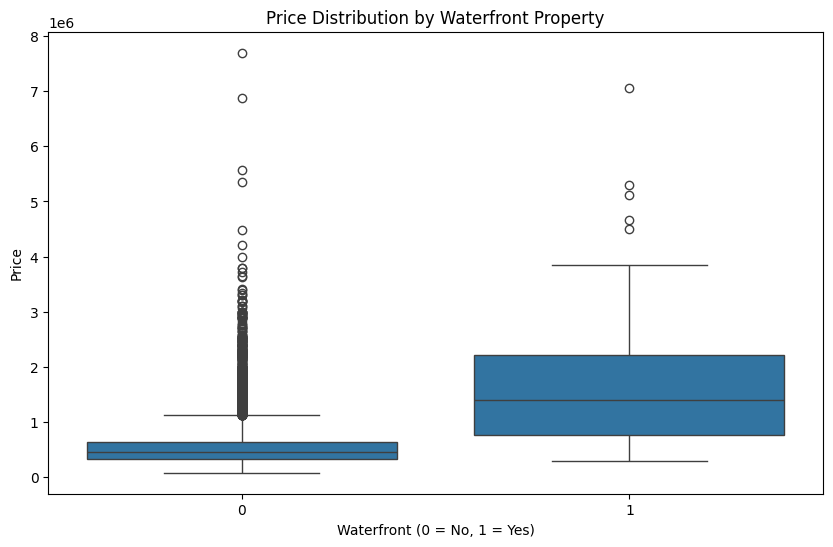

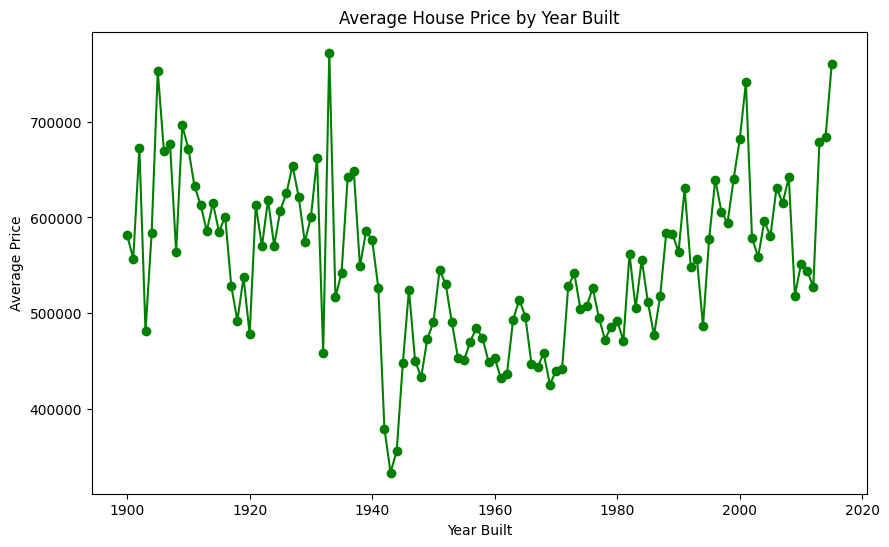

In [37]:
#1
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
house_prices_df = pd.read_csv('/content/kc_house_data.csv')

plt.figure(figsize=(10,6))
plt.hist(house_prices_df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

'''
from the plot we can observe that the data we have is right-skewed between 0-1 and from this observation we can see that the houses are pretty much
affordable in this range.
'''

#2

import seaborn as sns

# Create a scatter plot to show the relationship between sqft_living and price
plt.figure(figsize=(10,6))
sns.scatterplot(x='sqft_living', y='price', data=house_prices_df, color='blue')

plt.title('Relationship Between Square Footage and Price')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.show()
'''
from the below plot we can see that for rise in square footage the prices are also constantly increased bu tfor one class at 14000 the price is dropped which we can consider this as oulier.
'''

#3

# Select relevant numeric columns for correlation
correlation_matrix = house_prices_df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors']].corr()

# Plot the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap of Numeric Features')
plt.show()
'''
from the corelation matrix we can find that the square footage has highest positive corelation with price and no.of bathrooms ha s
also have a reasonable impact on the price of Houses.
'''

#4
# Create a boxplot comparing waterfront vs. non-waterfront house prices
plt.figure(figsize=(10,6))
sns.boxplot(x='waterfront', y='price', data=house_prices_df)

plt.title('Price Distribution by Waterfront Property')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price')
plt.show()

'''
so for water front property the every quartile range is increased when compared to properties without water front properties. By this observation we can see that
for properties with water front the price range is higher.
'''

#5
# Group by year and calculate the average price for each year
avg_price_by_year = house_prices_df.groupby('yr_built')['price'].mean().reset_index()

# Plot a line chart of average house prices by year built
plt.figure(figsize=(10,6))
plt.plot(avg_price_by_year['yr_built'], avg_price_by_year['price'], marker='o', color='green')

plt.title('Average House Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Price')
plt.show()

'''
By observing the plot we can see that avg price of houses peaked at 1930 and after that the range is achieved in 2020. from  this graph we can see that there should be some occurence of
economic crisis at 1930 similar to the impact of 2020's covid so that it may have impact on the price pf house holds.
'''
